# 카카오뱅크 AI 챗봇 모호성 통합 평가 프레임워크

**4단계 파이프라인**으로 모호성 평가를 통합합니다.

| 단계 | 내용 | 핵심 지표 |
|------|------|-----------|
| **Stage 1** | CheckEval 모호성 어노테이션 | Ambiguity Score (0=명확 → 1=모호) |
| **Stage 2** | 모호 상태 → 직접 API 호출 평가 (Baseline) | Match Accuracy, Match Score |
| **Stage 3a** | 멀티 턴 명확화 대화 → API 호출 평가 | MRR, Recall@N |
| **Stage 3b** | 명확화 후 CheckEval 재측정 | Ambiguity Reduction |
| **Stage 4** | 비교 분석 | 상관관계, 단계별 개선 효과 |

> **데이터**: 카카오뱅크 AI 챗봇 모호성 벤치마크 45 시나리오 (5 modality × 3 element × 3)


In [1]:
import sys, os, json, re, asyncio
from pathlib import Path
from collections import defaultdict
from statistics import mean
from datetime import datetime
from typing import Any, Dict, List, Optional, Sequence

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from IPython.display import display, Markdown
from openai import AsyncOpenAI
import nest_asyncio
nest_asyncio.apply()

# 한글 폰트
_font_set = False
for _fn in ['NanumGothic', 'Malgun Gothic', 'AppleGothic']:
    if any(_fn.lower() in f.name.lower() for f in mpl.font_manager.fontManager.ttflist):
        plt.rcParams['font.family'] = _fn
        _font_set = True
        break
if not _font_set:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
import warnings; warnings.filterwarnings('ignore', message='.*findfont.*')
print('✓ Imports OK')


✓ Imports OK


In [2]:
ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
sys.path.insert(0, str(ROOT / 'src'))

DATA_PATH       = ROOT / 'data' / 'ambigous_query' / 'ambiguity_scenarios.json'
API_SPECS_PATH  = ROOT / 'data' / 'ambigous_query' / 'kakaobank_api_specs.json'
QUESTION_DIR    = ROOT / 'prompt' / 'ambiguity_questions'
RESULTS_DIR     = ROOT / 'results' / 'ambiguity_framework'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL                   = 'gpt-5.4-mini'
MAX_CLARIFICATION_TURNS = 10
QUESTION_VERSION        = 'filtered'
TEMPERATURE             = 0.0
MAX_CONCURRENCY         = 8

# 어노테이션 결과 저장 경로 (모델/버전별 고유 파일명)
ANNOTATED_PATH = DATA_PATH.parent / 'ambiguity_scenarios_annotated.json'

# .env 파일 로드 (우선순위: 환경변수 > .env > getpass)
from dotenv import load_dotenv
for _env_path in [
    ROOT / '.env',
    ROOT.parent / '.env',
    Path.home() / 'convcodeworld' / '.env',
]:
    if _env_path.exists():
        load_dotenv(_env_path, override=False)
        print(f'✓ .env 로드: {_env_path}')
        break

import getpass
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY') or getpass.getpass('OPENAI_API_KEY: ')

print(f'ROOT:            {ROOT}')
print(f'DATA_PATH:       {chr(10003)} {DATA_PATH.name}')
print(f'ANNOTATED_PATH:  {chr(10003) if ANNOTATED_PATH.exists() else chr(9900)} {ANNOTATED_PATH.name}')
print(f'MODEL:           {MODEL}')
print(f'QUESTION_VERSION:{QUESTION_VERSION}')
print(f'API Key:         {"✓ 로드됨" if OPENAI_API_KEY else "✗ 없음"}')


✓ .env 로드: /home/mikelee/CheckEval/.env
ROOT:            /home/mikelee/CheckEval
DATA_PATH:       ✓ ambiguity_scenarios.json
ANNOTATED_PATH:  ✓ ambiguity_scenarios_annotated.json
MODEL:           gpt-5.4-mini
QUESTION_VERSION:filtered
API Key:         ✓ 로드됨


---
## Section 1: 데이터 로딩 및 개요


In [3]:
# 어노테이션 파일이 있으면 로드, 없으면 원본 로드
_load_path = ANNOTATED_PATH if ANNOTATED_PATH.exists() else DATA_PATH
with open(_load_path, encoding='utf-8') as f:
    raw_data = json.load(f)
scenarios      = raw_data['scenarios']
meta           = raw_data['_meta']
scenario_by_id = {s['scenario_id']: s for s in scenarios}

with open(API_SPECS_PATH, encoding='utf-8') as f:
    api_specs = json.load(f)

_src = 'annotated' if ANNOTATED_PATH.exists() else 'original'
print(f'✓ Scenarios: {len(scenarios)}개 ({_src}: {_load_path.name})')
print(f'✓ API services: {list(api_specs.get("apis", {}).keys())}')


✓ Scenarios: 45개 (annotated: ambiguity_scenarios_annotated.json)
✓ API services: ['AI_SEARCH', 'AI_TRANSFER', 'AI_CALCULATOR', 'AI_GROUP_TREASURER']


In [4]:
# Taxonomy 분포
overview_df = pd.DataFrame([{
    'scenario_id': s['scenario_id'],
    'modality': s['taxonomy']['modality'],
    'element':  s['taxonomy']['element'],
    'service':  s['service'],
    'annotated': 'checkeval_annotation' in s,
} for s in scenarios])

pivot = overview_df.groupby(['modality', 'element']).size().unstack(fill_value=0)
display(pivot)
print(f'\nCheckEval 어노테이션 완료: {overview_df["annotated"].sum()}/{len(scenarios)}개')


element,대화 문맥(Dialogue Context),사용자 발화(User Utterance),지식 베이스(Knowledge Base)
modality,,,
결핍(Emptiness),3,3,3
다중성(Multiplicity),3,3,3
모순(Clash),3,3,3
유동성(Fluidity),3,3,3
포괄성(Generality),3,3,3



CheckEval 어노테이션 완료: 45/45개


---
## Stage 1: CheckEval 모호성 어노테이션

[`evaluate_ambiguity_checkeval.py`](../src/evaluate_ambiguity_checkeval.py)를 이용해  
8개 차원 × sub-dimension 기준으로 각 시나리오의 모호성 점수를 계산합니다.

- **점수 체계**: `ambiguity_score = 1 − clarity_score`  → **0 = 명확, 1 = 모호**
- 이미 어노테이션된 결과(`checkeval_annotation` 필드)가 있으면 바로 로드합니다.
- 없는 경우 이 노트북에서 직접 실행합니다.


In [5]:
# 시나리오 내 checkeval_annotation 필드에서 로드
annotations = {
    s['scenario_id']: s['checkeval_annotation']
    for s in scenarios
    if 'checkeval_annotation' in s
}
print(f'어노테이션 로드: {len(annotations)}/{len(scenarios)}개')
if len(annotations) < len(scenarios):
    missing = [s['scenario_id'] for s in scenarios if s['scenario_id'] not in annotations]
    print(f'미완료: {missing}')
    print('  → 아래 셀(Stage 1 실행)을 먼저 실행하세요')


어노테이션 로드: 45/45개


In [ ]:
# ── Stage 1: 항상 실행 — 어노테이션 후 ANNOTATED_PATH에 저장 ────────────
from evaluate_ambiguity_checkeval import (
    load_dimension_questions, build_ambiguity_prompt,
    parse_yes_no_answers, dimensions_for_mode, evaluate_records,
)

question_bundles = load_dimension_questions(QUESTION_DIR, QUESTION_VERSION)

eval_records = []
for scenario in scenarios:
    dims = dimensions_for_mode(scenario, 'matched')
    for dim in dims:
        bundle = question_bundles[dim]
        for sub_name, sub_questions in bundle.sub_dimensions.items():
            eval_records.append({
                'mode': 'matched', 'scenario_id': scenario['scenario_id'],
                'dimension': dim, 'sub_dimension': sub_name,
                'taxonomy_code': scenario['taxonomy'].get('code'),
                'taxonomy_modality': scenario['taxonomy'].get('modality'),
                'taxonomy_element': scenario['taxonomy'].get('element'),
                'title': scenario.get('title'),
                'expected_questions': len(sub_questions),
                'prompt': build_ambiguity_prompt(
                    scenario=scenario, dimension=dim,
                    definition=bundle.definition, questions=sub_questions,
                ),
            })

print(f'평가 레코드: {len(eval_records)}개 → {MODEL} API 호출 중...')

async def _run_checkeval():
    async with AsyncOpenAI(api_key=OPENAI_API_KEY) as client:
        return await evaluate_records(
            records=eval_records, client=client,
            model=MODEL, max_concurrency=MAX_CONCURRENCY,
        )
rows = asyncio.get_event_loop().run_until_complete(_run_checkeval())

# 시나리오별 집계 및 annotations dict 갱신
by_scenario = defaultdict(lambda: {'scores': [], 'by_dim': defaultdict(list)})
for row in rows:
    if row.get('score') is None: continue
    sid = row['scenario_id']
    by_scenario[sid]['scores'].append(float(row['score']))
    by_scenario[sid]['by_dim'][row['dimension']].append(float(row['score']))

annotations = {}
for sid, data in by_scenario.items():
    clarity = mean(data['scores'])
    ann = {
        'ambiguity_score': round(1 - clarity, 4),
        'clarity_score':   round(clarity, 4),
        'dimension_ambiguity_scores': {
            d: round(1 - mean(vs), 4) for d, vs in data['by_dim'].items()
        },
        'eval_mode': 'matched', 'model': MODEL, 'question_version': QUESTION_VERSION,
    }
    annotations[sid] = ann
    scenario_by_id[sid]['checkeval_annotation'] = ann

# 원본과 별도 파일로 저장 (원본 덮어쓰지 않음)
annotated_data = dict(raw_data)
annotated_data['scenarios'] = list(scenario_by_id.values())
annotated_data['_annotation_meta'] = {
    'model': MODEL, 'question_version': QUESTION_VERSION,
    'mode': 'matched', 'annotated_count': len(annotations),
}
with open(ANNOTATED_PATH, 'w', encoding='utf-8') as f:
    json.dump(annotated_data, f, ensure_ascii=False, indent=2)

print(f'✓ {len(annotations)}개 어노테이션 완료')
print(f'✓ 저장: {ANNOTATED_PATH.name}')


In [6]:
# 어노테이션 통계
ann_df = pd.DataFrame([{
    'scenario_id': s['scenario_id'],
    'modality': s['taxonomy']['modality'].split('(')[-1].rstrip(')'),
    'element':  s['taxonomy']['element'].split('(')[-1].rstrip(')'),
    'ambiguity_score': annotations.get(s['scenario_id'], {}).get('ambiguity_score'),
} for s in scenarios])

print('=== Ambiguity Score 요약 ===')
print(ann_df['ambiguity_score'].describe().round(4))


=== Ambiguity Score 요약 ===
count    45.0000
mean      0.5539
std       0.1773
min       0.1562
25%       0.4325
50%       0.5811
75%       0.6615
max       0.8785
Name: ambiguity_score, dtype: float64


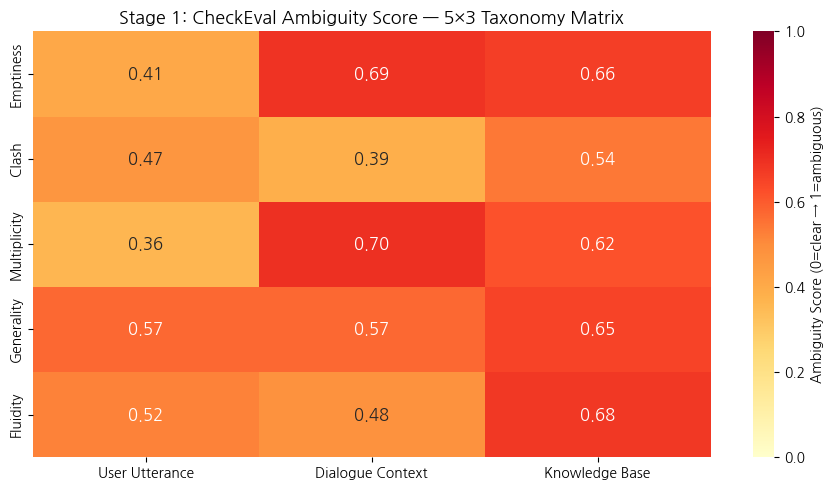

In [7]:
# 5×3 Taxonomy 히트맵
MODALITIES   = ['Emptiness', 'Clash', 'Multiplicity', 'Generality', 'Fluidity']
ELEM_KEYS    = ['User Utterance', 'Dialogue Context', 'Knowledge Base']

def mod_idx(s):
    low = s.lower()
    for i, m in enumerate(MODALITIES):
        if m.lower() in low: return i
    return None

def elem_idx(s):
    low = s.lower()
    for i, e in enumerate(ELEM_KEYS):
        if e.lower() in low: return i
    return None

mat = np.full((5, 3), np.nan)
cnt = np.zeros((5, 3))
for sc in scenarios:
    sid = sc['scenario_id']
    if sid not in annotations: continue
    mi = mod_idx(sc['taxonomy']['modality'])
    ei = elem_idx(sc['taxonomy']['element'])
    v  = annotations[sid].get('ambiguity_score')
    if mi is not None and ei is not None and v is not None:
        mat[mi, ei] = np.nansum([mat[mi, ei] if not np.isnan(mat[mi, ei]) else 0, v])
        cnt[mi, ei] += 1

avg_mat = np.divide(mat, cnt, where=cnt > 0, out=np.full_like(mat, np.nan))

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(np.nan_to_num(avg_mat), ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
            mask=np.isnan(avg_mat), annot=True, fmt='.2f',
            annot_kws={'fontsize': 12},
            xticklabels=ELEM_KEYS, yticklabels=MODALITIES,
            cbar_kws={'label': 'Ambiguity Score (0=clear → 1=ambiguous)'})
ax.set_title('Stage 1: CheckEval Ambiguity Score — 5×3 Taxonomy Matrix', fontsize=13)
plt.tight_layout()
plt.show()


---
## Stage 2: 모호 상태 → 직접 API 호출 평가 (Baseline)

명확화 없이 모호한 쿼리 그대로 LLM에게 API를 즉시 호출하도록 지시합니다.  
`gold_api.candidate_apis` 중 어느 것과 일치하는지 평가합니다.

- **목적**: 모호한 상태에서의 API 호출 능력 측정 (하한선 설정)
- **성공 기준**: 예측 endpoint가 `candidate_apis` 중 하나와 일치


In [8]:
# ── 공용 유틸리티 ────────────────────────────────────────────────────────
import random as _random

def format_api_specs_compact(api_specs: dict, service_name: str = None) -> str:
    lines = []
    apis = api_specs["apis"]
    targets = (
        {service_name: apis[service_name]}
        if service_name and service_name in apis
        else apis
    )
    for svc_name, svc_data in targets.items():
        lines.append(f"# {svc_name}")
        lines.append(svc_data.get("description", ""))
        lines.append("")
        for ep in svc_data.get("endpoints", []):
            lines.append(f"## [{ep['api_id']}] {ep.get('name', '')}")
            lines.append(f"  {ep['method']} {ep['endpoint']}")
            lines.append(f"  설명: {ep.get('description', '')}")
            req_params, opt_params = [], []
            for pname, pinfo in ep.get("request", {}).items():
                if not isinstance(pinfo, dict):
                    continue
                ptype  = pinfo.get("type", "string")
                desc   = pinfo.get("description", "")
                enums  = pinfo.get("enum", [])
                enum_s = f" [{'/'.join(enums)}]" if enums else ""
                entry  = f"    - {pname} ({ptype}{enum_s}): {desc}"
                if pinfo.get("required"):
                    req_params.append(entry + " [필수]")
                else:
                    opt_params.append(entry)
            if req_params:
                lines.append("  필수 파라미터:")
                lines.extend(req_params)
            if opt_params:
                lines.append("  선택 파라미터:")
                lines.extend(opt_params)
            lines.append("")
    return "\n".join(lines)


def format_conversation(conversation: list) -> str:
    return "\n".join(
        f"{'사용자' if t['role'] == 'user' else '어시스턴트'}: {t['content']}"
        for t in conversation
    )


def parse_json_response(text: str) -> dict:
    text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    m = re.search(r"\{[\s\S]*\}", text)
    if m:
        try:
            return json.loads(m.group())
        except json.JSONDecodeError:
            pass
    return {}


def _lookup_endpoint(api_id: str, api_specs: dict) -> str:
    for svc_data in api_specs["apis"].values():
        for ep in svc_data["endpoints"]:
            if ep["api_id"] == api_id:
                return f"{ep['method']} {ep['endpoint']}"
    return ""


def get_target_api(scenario: dict, mode: str = "first") -> Optional[dict]:
    """
    시나리오의 gold_api를 {api_id, endpoint, parameters, intent} 형태로 정규화.

    처리하는 gold_api 구조 6가지:
      ① candidate_apis 리스트 (dict 또는 str 원소)
      ② 단일 api_id 문자열
      ③ api_id: null + target_api 필드 (M-KB-2, G-KB-1)
      ④ candidates 리스트 (M-DC-2, G-DC-2, G-DC-3)
      ⑤ parse_A_api_1/2 (M-UU-2, M-UU-3)
      ⑥ api_id_1/endpoint_1 (F-UU-1, F-KB-1 — 유동성 두 단계)
    """
    gold = scenario["gold_api"]

    # ① candidate_apis 리스트 (dict 또는 str 원소)
    if "candidate_apis" in gold:
        lst = gold["candidate_apis"]
        if not lst:
            return None
        idx = _random.randint(0, len(lst) - 1) if mode == "random" else 0
        c   = lst[idx]
        if isinstance(c, str):
            return {
                "api_id":     c,
                "endpoint":   _lookup_endpoint(c, api_specs),
                "parameters": {},
                "intent":     c,
            }
        return {
            "api_id":     c["api_id"],
            "endpoint":   c.get("endpoint") or _lookup_endpoint(c["api_id"], api_specs),
            "parameters": c.get("parameters", {}),
            "intent":     c.get("intent", c["api_id"]),
        }

    # ② 단일 api_id
    if gold.get("api_id"):
        api_id   = gold["api_id"]
        endpoint = gold.get("endpoint") or _lookup_endpoint(api_id, api_specs)
        return {"api_id": api_id, "endpoint": endpoint,
                "parameters": gold.get("parameters", {}), "intent": api_id}

    # ③ api_id: null + target_api 필드
    if gold.get("api_id") is None and "target_api" in gold:
        ta     = gold["target_api"]
        api_id = ta.get("api_id")
        if not api_id:
            return None
        endpoint = ta.get("endpoint") or _lookup_endpoint(api_id, api_specs)
        params   = ta.get("known_parameters") or ta.get("parameters", {})
        return {"api_id": api_id, "endpoint": endpoint, "parameters": params, "intent": api_id}

    # ④ candidates 리스트
    if "candidates" in gold and isinstance(gold["candidates"], list):
        lst = gold["candidates"]
        if not lst:
            return None
        idx    = _random.randint(0, len(lst) - 1) if mode == "random" else 0
        c      = lst[idx]
        api_id = c.get("api_id", "")
        endpoint = c.get("endpoint") or _lookup_endpoint(api_id, api_specs)
        return {
            "api_id":     api_id,
            "endpoint":   endpoint,
            "parameters": c.get("parameters", {}),
            "intent":     c.get("product", api_id),
        }

    # ⑤ parse_A_api_1 / parse_A_api_2
    if "parse_A_api_1" in gold:
        key = (
            "parse_A_api_2"
            if mode == "random" and _random.random() > 0.5 and "parse_A_api_2" in gold
            else "parse_A_api_1"
        )
        ta       = gold[key]
        api_id   = ta["api_id"]
        endpoint = ta.get("endpoint") or _lookup_endpoint(api_id, api_specs)
        return {
            "api_id":     api_id,
            "endpoint":   endpoint,
            "parameters": ta.get("parameters", {}),
            "intent":     api_id,
        }

    # ⑥ api_id_1 / endpoint_1 (유동성 두 단계 API)
    if "api_id_1" in gold:
        api_id   = gold["api_id_1"]
        endpoint = gold.get("endpoint_1") or _lookup_endpoint(api_id, api_specs)
        params   = gold.get("parameters_1") or gold.get("parameters", {})
        return {
            "api_id":     api_id,
            "endpoint":   endpoint,
            "parameters": params,
            "intent":     f"{api_id} (두 단계 중 첫 번째)",
        }

    return None


def evaluate_api_match(predicted: dict, target_api: dict) -> dict:
    """
    예측된 API 호출 결정과 정답 API dict를 비교하여 일치 지표를 반환.
    predicted  : Resolver 또는 Baseline이 반환한 dict (api_id, endpoint 필드 포함)
    target_api : get_target_api()로 정규화된 정답 API dict
    """
    pred_id  = str(predicted.get("api_id") or "").strip().upper()
    true_id  = str(target_api.get("api_id") or "").strip().upper()
    id_match = bool(pred_id and pred_id == true_id)

    def path_only(s):
        parts = (s or "").split()
        return parts[-1].lower().rstrip("/") if parts else ""

    ep_match    = path_only(predicted.get("endpoint", "")) == path_only(target_api.get("endpoint", ""))
    true_params = {k: v for k, v in target_api.get("parameters", {}).items()
                   if v not in ("PENDING_USER_AUTH", "PENDING", None)}
    pred_params = predicted.get("parameters") or {}
    param_cov   = (sum(1 for k in true_params if k in pred_params) / len(true_params)
                   if true_params else 1.0)

    return {
        "called":           True,
        "api_id_match":     id_match,
        "endpoint_match":   ep_match,
        "param_coverage":   round(param_cov, 2),
        "overall":          id_match and ep_match,
        "predicted_api_id": pred_id,
        "true_api_id":      true_id,
    }


def evaluate_api_match_any(predicted: dict, candidates: list) -> dict:
    """
    Baseline용: 후보 API 목록 중 하나라도 일치하면 성공으로 처리.
    candidates 원소가 dict 또는 str(api_id) 모두 처리.
    """
    if not predicted or not candidates:
        return {"any_match": False, "best_score": 0.0, "matched_api_id": None}
    best_score, best_id = 0.0, None
    for c in candidates:
        if isinstance(c, str):
            target = {"api_id": c, "endpoint": _lookup_endpoint(c, api_specs), "parameters": {}}
        else:
            target = {"api_id": c.get("api_id", ""), "endpoint": c.get("endpoint", ""),
                      "parameters": c.get("parameters", {})}
        m     = evaluate_api_match(predicted, target)
        score = (0.6 if m["api_id_match"] else 0.0) + (0.4 if m["endpoint_match"] else 0.0)
        if score > best_score:
            best_score = score
            best_id    = target["api_id"]
    return {"any_match": best_score > 0, "best_score": round(best_score, 3), "matched_api_id": best_id}


print("✓ 공용 유틸리티 정의 완료")


✓ 공용 유틸리티 정의 완료


In [9]:
# ── Baseline: 직접 API 호출 ──────────────────────────────────────────────
BASELINE_SYSTEM = (
    "당신은 카카오뱅크 AI 챗봇입니다.\n"
    "대화 내용과 최종 사용자 요청(모호할 수 있음)이 주어지면, 가장 적합한 API를 즉시 호출하세요.\n"
    "의도가 불명확하더라도 최선의 판단으로 API를 선택하세요.\n\n"
    "## 응답 형식 (반드시 순수 JSON만 출력)\n"
    '{"action": "call_api", "reasoning": "선택 근거", '
    '"api_id": "예: AT-05", "endpoint": "예: POST /api/v1/transfer/execute", '
    '"parameters": {...}}'
)


async def run_baseline_scenario(scenario: dict, client: AsyncOpenAI) -> dict:
    conv     = format_conversation(scenario["conversation"])
    api_text = format_api_specs_compact(api_specs, scenario.get("service"))
    user_msg = (
        f"## 이전 대화 컨텍스트\n{conv}\n\n"
        f"## 처리할 발화 (모호할 수 있음)\n\"{scenario['ambiguous_query']}\"\n\n"
        f"## 사용 가능한 API 명세\n{api_text}\n\n"
        "가장 적합한 API를 호출하세요. 반드시 순수 JSON으로만 응답하세요."
    )
    try:
        resp = await client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "system", "content": BASELINE_SYSTEM},
                      {"role": "user",   "content": user_msg}],
            temperature=TEMPERATURE, max_completion_tokens=300,
        )
        raw       = resp.choices[0].message.content or ""
        predicted = parse_json_response(raw)
        error     = None
    except Exception as e:
        raw, predicted, error = "", {}, str(e)

    candidates = scenario.get("gold_api", {}).get("candidate_apis", [])
    match      = evaluate_api_match_any(predicted, candidates)
    return {
        "scenario_id":        scenario["scenario_id"],
        "title":              scenario["title"],
        "taxonomy_modality":  scenario["taxonomy"]["modality"],
        "taxonomy_element":   scenario["taxonomy"]["element"],
        "service":            scenario["service"],
        "predicted_api_id":   predicted.get("api_id"),
        "predicted_endpoint": predicted.get("endpoint"),
        "any_match":          match["any_match"],
        "match_score":        match["best_score"],
        "matched_api_id":     match["matched_api_id"],
        "num_candidates":     len(candidates),
        "error":              error,
    }


BASELINE_PATH = RESULTS_DIR / f"baseline_{MODEL.replace('/', '_')}.jsonl"


async def _run_baseline_all():
    sem = asyncio.Semaphore(MAX_CONCURRENCY)
    async with AsyncOpenAI(api_key=OPENAI_API_KEY) as client:
        async def _one(s):
            async with sem:
                return await run_baseline_scenario(s, client)
        return await asyncio.gather(*[_one(s) for s in scenarios])


if BASELINE_PATH.exists():
    baseline_results = [json.loads(l) for l in
                        BASELINE_PATH.read_text(encoding="utf-8").splitlines() if l.strip()]
    print(f"캐시 로드: {len(baseline_results)}개 ({BASELINE_PATH.name})")
else:
    print(f"Baseline 평가 시작 ({len(scenarios)}개 시나리오)...")
    baseline_results = asyncio.get_event_loop().run_until_complete(_run_baseline_all())
    BASELINE_PATH.write_text(
        "\n".join(json.dumps(r, ensure_ascii=False) for r in baseline_results),
        encoding="utf-8"
    )
    print(f"✓ 저장: {BASELINE_PATH}")

baseline_by_id = {r["scenario_id"]: r for r in baseline_results}

any_match_list   = [r["any_match"]   for r in baseline_results]
match_score_list = [r["match_score"] for r in baseline_results]
print(f"\n=== Stage 2: Baseline 결과 ===")
print(f"Any-match Accuracy : {sum(any_match_list)}/{len(any_match_list)} = {mean(any_match_list):.3f}")
print(f"Mean Match Score   : {mean(match_score_list):.3f}")


캐시 로드: 45개 (baseline_gpt-5.4-mini.jsonl)

=== Stage 2: Baseline 결과 ===
Any-match Accuracy : 4/45 = 0.089
Mean Match Score   : 0.089


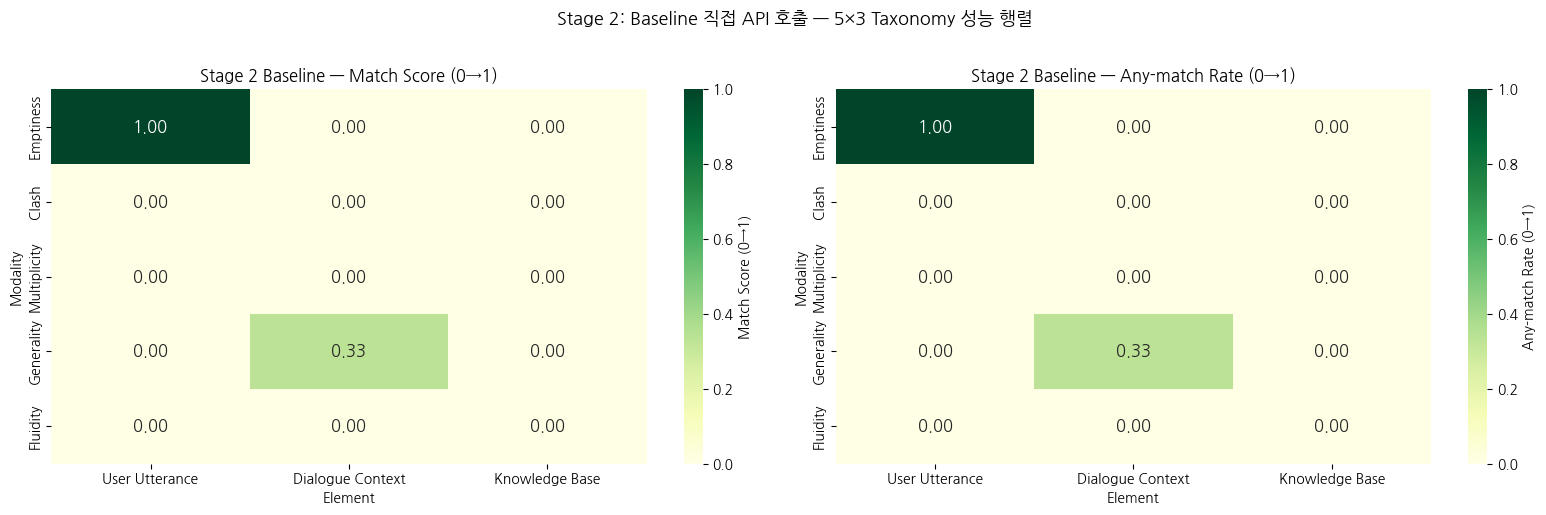


=== Taxonomy별 Baseline 성능 ===
    Modality          Element  Match Score  Any-match
   Emptiness   User Utterance        1.000      1.000
   Emptiness Dialogue Context        0.000      0.000
   Emptiness   Knowledge Base        0.000      0.000
       Clash   User Utterance        0.000      0.000
       Clash Dialogue Context        0.000      0.000
       Clash   Knowledge Base        0.000      0.000
Multiplicity   User Utterance        0.000      0.000
Multiplicity Dialogue Context        0.000      0.000
Multiplicity   Knowledge Base        0.000      0.000
  Generality   User Utterance        0.000      0.000
  Generality Dialogue Context        0.333      0.333
  Generality   Knowledge Base        0.000      0.000
    Fluidity   User Utterance        0.000      0.000
    Fluidity Dialogue Context        0.000      0.000
    Fluidity   Knowledge Base        0.000      0.000


In [10]:
# Stage 2: Baseline — 5×3 Taxonomy 히트맵
base_df = pd.DataFrame(baseline_results)

mat_score = np.full((5, 3), np.nan)
mat_match = np.full((5, 3), np.nan)
cnt       = np.zeros((5, 3))

for _, row in base_df.iterrows():
    mi = mod_idx(row['taxonomy_modality'])
    ei = elem_idx(row['taxonomy_element'])
    if mi is not None and ei is not None:
        mat_score[mi, ei] = np.nansum([mat_score[mi, ei] if not np.isnan(mat_score[mi, ei]) else 0,
                                       row.get('match_score') or 0.0])
        mat_match[mi, ei] = np.nansum([mat_match[mi, ei] if not np.isnan(mat_match[mi, ei]) else 0,
                                       float(row.get('any_match', False))])
        cnt[mi, ei] += 1

avg_score = np.divide(mat_score, cnt, where=cnt > 0, out=np.full_like(mat_score, np.nan))
avg_match = np.divide(mat_match, cnt, where=cnt > 0, out=np.full_like(mat_match, np.nan))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, mat, title in [
    (axes[0], avg_score, 'Match Score (0→1)'),
    (axes[1], avg_match, 'Any-match Rate (0→1)'),
]:
    sns.heatmap(np.nan_to_num(mat), ax=ax, cmap='YlGn', vmin=0, vmax=1,
                mask=np.isnan(mat), annot=True, fmt='.2f', annot_kws={'fontsize': 12},
                xticklabels=ELEM_KEYS, yticklabels=MODALITIES,
                cbar_kws={'label': title})
    ax.set_title(f'Stage 2 Baseline — {title}', fontsize=12)
    ax.set_xlabel('Element'); ax.set_ylabel('Modality')

plt.suptitle('Stage 2: Baseline 직접 API 호출 — 5×3 Taxonomy 성능 행렬', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# 수치 요약 테이블
print('\n=== Taxonomy별 Baseline 성능 ===')
rows = []
for mi, mod in enumerate(MODALITIES):
    for ei, elem in enumerate(ELEM_KEYS):
        if not np.isnan(avg_score[mi, ei]):
            rows.append({'Modality': mod, 'Element': elem,
                         'Match Score': round(avg_score[mi, ei], 3),
                         'Any-match':   round(avg_match[mi, ei], 3)})
print(pd.DataFrame(rows).to_string(index=False))


---
## Stage 3a: 멀티 턴 명확화 대화 → API 호출 평가

`AmbiguityResolver`가 명확화 질문을 생성하고 `UserSimulator`가 목표 API 방향으로 답변합니다.  
최종 API 호출을 `candidate_apis`와 비교해 **MRR**, **Recall@N**을 계산합니다.


In [11]:
# ── LLMClient ────────────────────────────────────────────────────────────
class LLMClient:
    def __init__(self, api_key, model, base_url=None, temperature=0.0):
        kw = {"api_key": api_key}
        if base_url:
            kw["base_url"] = base_url
        self._client     = AsyncOpenAI(**kw)
        self.model       = model
        self.temperature = temperature

    async def chat(self, messages, max_tokens=500, **kw) -> str:
        resp = await self._client.chat.completions.create(
            model=self.model, messages=messages,
            temperature=self.temperature, max_completion_tokens=max_tokens, **kw,
        )
        return resp.choices[0].message.content or ""

    async def chat_json(self, messages, **kw) -> dict:
        return parse_json_response(await self.chat(messages, **kw))

    async def close(self):
        await self._client.close()


# ── AmbiguityResolver 프롬프트 ────────────────────────────────────────────
RESOLVER_SYSTEM_TEMPLATE = (
    "당신은 카카오뱅크 AI 챗봇입니다. 사용자 요청을 분석하여 적절한 API를 호출해야 합니다.\n\n"
    "## 사용 가능한 API 명세\n"
    "{api_specs}\n\n"
    "## 응답 형식 (반드시 순수 JSON만 출력)\n\n"
    "사용자 의도가 **불명확**하여 어떤 API를 호출할지 결정할 수 없을 때:\n"
    '{{"action": "ask_clarification", '
    '"reasoning": "모호한 이유 한 문장", '
    '"question": "한국어로 핵심 질문 하나"}}\n\n'
    "사용자 의도가 **충분히 명확**하여 API를 특정할 수 있을 때:\n"
    '{{"action": "call_api", '
    '"reasoning": "선택 근거", '
    '"api_id": "예: AT-05", '
    '"endpoint": "예: POST /api/v1/transfer/execute", '
    '"parameters": {{...}}}}\n\n'
    "## 규칙\n"
    "- JSON 외 다른 텍스트 절대 금지\n"
    "- 명확화 질문은 한 번에 한 가지만\n"
    "- parameters에는 대화에서 확인된 값만 포함 (추측 금지, 미확인 필수값은 null)\n"
    "- 이미 충분한 정보가 있다면 즉시 call_api로 응답\n"
)

# ── UserSimulator 프롬프트 ────────────────────────────────────────────────
USER_SIMULATOR_SYSTEM_TEMPLATE = (
    "당신은 카카오뱅크 앱을 사용하는 고객입니다. 특정 금융 작업을 원합니다.\n\n"
    "## 당신의 실제 의도 (챗봇에게는 숨겨진 정보)\n"
    "- 호출하려는 API : {api_id} — {intent}\n"
    "- API 엔드포인트  : {endpoint}\n"
    "- 확인된 파라미터 : {parameters}\n"
    "- 상황 배경       : {context}\n\n"
    "## 답변 규칙\n"
    "1. 챗봇 질문에 자연스러운 한국어로 1~2문장 이내로 답하세요\n"
    "2. 당신의 진짜 의도({intent})가 전달되도록 명확하게 말하세요\n"
    "3. JSON · 코드 형식 사용 금지 — 일상 대화체만 사용\n"
    "4. 이미 이전 대화에서 언급한 정보는 반복하지 마세요\n"
)


# ── AmbiguityResolver ─────────────────────────────────────────────────────
class AmbiguityResolver:
    def __init__(self, api_specs: dict, llm: LLMClient):
        self.api_specs = api_specs
        self.llm       = llm

    def _system_prompt(self, service_name: Optional[str]) -> str:
        api_text = format_api_specs_compact(self.api_specs, service_name)
        return RESOLVER_SYSTEM_TEMPLATE.format(api_specs=api_text)

    def _build_messages(self, scenario: dict, clarification_history: list) -> list:
        """
        원본 대화 컨텍스트 + 명확화 교환 이력을 멀티턴 메시지로 조립.
        clarification_history: [(question_str, answer_str), ...]
        """
        system_prompt = self._system_prompt(scenario.get("service"))
        conv_lines = []
        for turn in scenario["conversation"]:
            label = "사용자" if turn["role"] == "user" else "어시스턴트"
            conv_lines.append(f"{label}: {turn['content']}")

        first_user_msg = (
            "[이전 대화 컨텍스트]\n"
            + "\n".join(conv_lines)
            + "\n\n[처리할 발화] "
            + scenario["ambiguous_query"]
        )

        messages = [{"role": "system", "content": system_prompt},
                    {"role": "user",   "content": first_user_msg}]

        for question, answer in clarification_history:
            messages.append({
                "role": "assistant",
                "content": json.dumps({"action": "ask_clarification", "question": question},
                                      ensure_ascii=False),
            })
            messages.append({"role": "user", "content": answer})

        return messages

    async def resolve(self, scenario: dict, clarification_history: list) -> dict:
        messages = self._build_messages(scenario, clarification_history)
        result   = await self.llm.chat_json(messages)
        if "action" not in result:
            result["action"] = "error"
        return result


# ── UserSimulator ─────────────────────────────────────────────────────────
class UserSimulator:
    def __init__(self, target_api: dict, scenario: dict, llm: LLMClient):
        self.target_api = target_api
        self.scenario   = scenario
        self.llm        = llm

    def _system_prompt(self) -> str:
        ta = self.target_api
        params = {k: v for k, v in ta.get("parameters", {}).items()
                  if v not in ("PENDING_USER_AUTH", "PENDING", None)}
        return USER_SIMULATOR_SYSTEM_TEMPLATE.format(
            api_id     = ta.get("api_id", ""),
            intent     = ta.get("intent", ""),
            endpoint   = ta.get("endpoint", ""),
            parameters = json.dumps(params, ensure_ascii=False),
            context    = self.scenario.get("ambiguity_reason", ""),
        )

    async def answer(self, question: str, clarification_history: list) -> str:
        history_lines = []
        for q, a in clarification_history:
            history_lines.append(f"챗봇: {q}")
            history_lines.append(f"나  : {a}")
        history_text = "\n".join(history_lines) if history_lines else "(첫 번째 질문)"
        user_msg = (
            f"[지금까지 명확화 대화]\n{history_text}\n\n"
            f"[챗봇 최근 질문] {question}\n\n"
            f"위 질문에 답하세요. 당신의 목표 의도: {self.target_api.get('intent', '')}"
        )
        return await self.llm.chat(
            [{"role": "system", "content": self._system_prompt()},
             {"role": "user",   "content": user_msg}],
            max_tokens=150,
        )


print("✓ LLMClient / AmbiguityResolver / UserSimulator 정의 완료")


✓ LLMClient / AmbiguityResolver / UserSimulator 정의 완료


In [12]:
# ── 멀티 턴 평가 루프 ─────────────────────────────────────────────────────
async def run_multiturn_scenario(
    scenario: dict, llm: LLMClient,
    max_turns: int = MAX_CLARIFICATION_TURNS,
    verbose: bool = False,
) -> dict:
    target_api = get_target_api(scenario, mode="first")
    if target_api is None:
        return {
            "scenario_id":             scenario["scenario_id"],
            "title":                   scenario["title"],
            "taxonomy_modality":       scenario["taxonomy"]["modality"],
            "taxonomy_element":        scenario["taxonomy"]["element"],
            "service":                 scenario["service"],
            "target_api_id":           None,
            "predicted_api_id":        None,
            "resolution_turn":         None,
            "num_clarification_turns": 0,
            "mrr_score":               0.0,
            "any_match":               False,
            "match_score":             0.0,
            "conversation_log":        [],
            "clarif_history":          [],
            "skipped":                 True,
        }

    resolver  = AmbiguityResolver(api_specs, llm)
    simulator = UserSimulator(target_api, scenario, llm)

    clarif_history: list = []   # [(question, answer), ...]
    conv_log:       list = []
    final_result         = {}
    resolution_turn      = None

    for turn in range(1, max_turns + 2):
        force_call = (turn > max_turns)
        result     = await resolver.resolve(scenario, clarif_history)
        action     = result.get("action", "error")

        if verbose:
            print(f"  Turn {turn} | {action} | {result.get('reasoning', '')[:80]}")

        if action == "ask_clarification" and not force_call:
            q   = result.get("question", "")
            ans = await simulator.answer(q, clarif_history)
            clarif_history.append((q, ans))
            conv_log.append({"turn": turn, "role": "assistant", "content": q,   "action": "ask_clarification"})
            conv_log.append({"turn": turn, "role": "user",      "content": ans, "action": "user_response"})
            if verbose:
                print(f"    Q: {q}")
                print(f"    A: {ans}")
        else:
            conv_log.append({"turn": turn, "role": "assistant",
                             "content": json.dumps(result, ensure_ascii=False), "action": "call_api"})
            final_result    = result
            resolution_turn = turn
            if verbose:
                m      = evaluate_api_match(result, target_api)
                status = f"✓ {m['true_api_id']}" if m["overall"] else "✗ 불일치"
                print(f"  → API: {result.get('api_id')} {result.get('endpoint')} | {status}")
            break

    match = evaluate_api_match(final_result, target_api) if final_result else {
        "overall": False, "api_id_match": False, "endpoint_match": False,
        "param_coverage": 0.0, "predicted_api_id": None,
    }
    is_correct = match.get("overall", False)
    mrr        = (1.0 / resolution_turn) if (is_correct and resolution_turn) else 0.0

    return {
        "scenario_id":             scenario["scenario_id"],
        "title":                   scenario["title"],
        "taxonomy_modality":       scenario["taxonomy"]["modality"],
        "taxonomy_element":        scenario["taxonomy"]["element"],
        "service":                 scenario["service"],
        "target_api_id":           target_api["api_id"],
        "predicted_api_id":        final_result.get("api_id"),
        "resolution_turn":         resolution_turn,
        "num_clarification_turns": len(clarif_history),
        "mrr_score":               round(mrr, 4),
        "any_match":               is_correct,
        "match_score":             (0.6 if match["api_id_match"] else 0.0) +
                                   (0.4 if match["endpoint_match"] else 0.0),
        "conversation_log":        conv_log,
        "clarif_history":          [{"question": q, "answer": a} for q, a in clarif_history],
    }


print("✓ run_multiturn_scenario 정의 완료")


✓ run_multiturn_scenario 정의 완료


In [13]:
MULTITURN_PATH = RESULTS_DIR / f'multiturn_{MODEL.replace("/", "_")}.jsonl'

async def _run_multiturn_all():
    llm = LLMClient(api_key=OPENAI_API_KEY, model=MODEL, temperature=TEMPERATURE)
    sem = asyncio.Semaphore(MAX_CONCURRENCY)
    async def _one(s):
        async with sem:
            return await run_multiturn_scenario(s, llm)
    try:
        return list(await asyncio.gather(*[_one(s) for s in scenarios]))
    finally:
        await llm.close()


if MULTITURN_PATH.exists():
    multiturn_results = [json.loads(l) for l in
                         MULTITURN_PATH.read_text(encoding='utf-8').splitlines() if l.strip()]
    print(f'캐시 로드: {len(multiturn_results)}개 ({MULTITURN_PATH.name})')
else:
    print(f'멀티 턴 평가 시작 ({len(scenarios)}개, max_turns={MAX_CLARIFICATION_TURNS})...')
    multiturn_results = asyncio.get_event_loop().run_until_complete(_run_multiturn_all())
    MULTITURN_PATH.write_text(
        '\n'.join(json.dumps(r, ensure_ascii=False, default=str) for r in multiturn_results),
        encoding='utf-8'
    )
    print(f'✓ 저장: {MULTITURN_PATH}')

multiturn_by_id = {r['scenario_id']: r for r in multiturn_results}

mrr_list   = [r['mrr_score'] for r in multiturn_results]
match_list = [r['any_match'] for r in multiturn_results]
turn_list  = [r['num_clarification_turns'] for r in multiturn_results]
print(f'\n=== Stage 3a: Multi-turn 결과 ===')
print(f'MRR               : {mean(mrr_list):.3f}')
print(f'Any-match Rate    : {mean(match_list):.3f}')
print(f'Avg Clarif Turns  : {mean(turn_list):.2f}')
for n in [1, 2, 3]:
    r_at_n = sum(1 for r in multiturn_results if (r['resolution_turn'] or 99) <= n) / len(multiturn_results)
    print(f'Recall@{n}          : {r_at_n:.3f}')


멀티 턴 평가 시작 (45개, max_turns=10)...
✓ 저장: /home/mikelee/CheckEval/results/ambiguity_framework/multiturn_gpt-5.4-mini.jsonl

=== Stage 3a: Multi-turn 결과 ===
MRR               : 0.363
Any-match Rate    : 0.600
Avg Clarif Turns  : 1.78
Recall@1          : 0.289
Recall@2          : 0.844
Recall@3          : 0.867


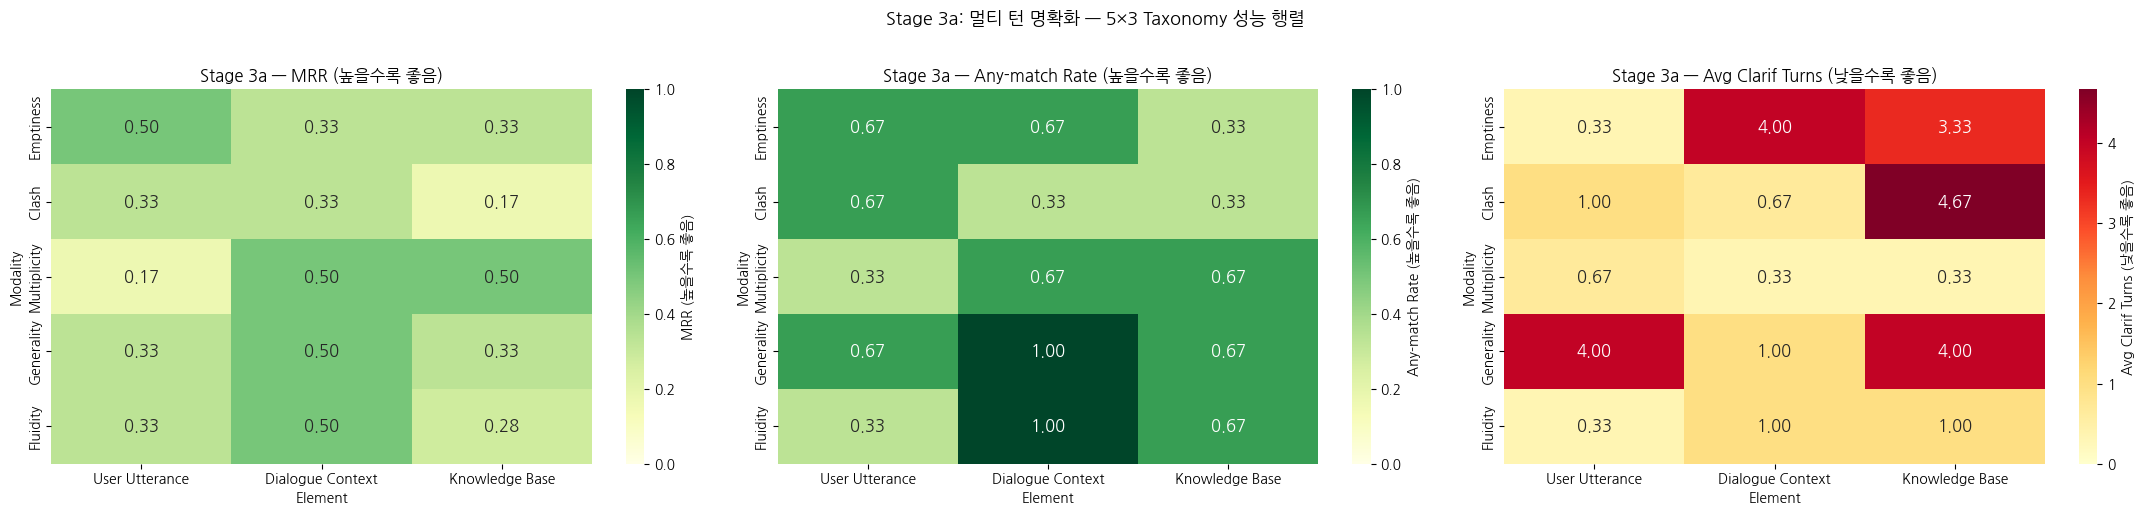


=== Taxonomy별 Multi-turn 성능 ===
    Modality          Element   MRR  Any-match  Avg Turns
   Emptiness   User Utterance 0.500      0.667       0.33
   Emptiness Dialogue Context 0.333      0.667       4.00
   Emptiness   Knowledge Base 0.333      0.333       3.33
       Clash   User Utterance 0.333      0.667       1.00
       Clash Dialogue Context 0.333      0.333       0.67
       Clash   Knowledge Base 0.167      0.333       4.67
Multiplicity   User Utterance 0.167      0.333       0.67
Multiplicity Dialogue Context 0.500      0.667       0.33
Multiplicity   Knowledge Base 0.500      0.667       0.33
  Generality   User Utterance 0.333      0.667       4.00
  Generality Dialogue Context 0.500      1.000       1.00
  Generality   Knowledge Base 0.333      0.667       4.00
    Fluidity   User Utterance 0.333      0.333       0.33
    Fluidity Dialogue Context 0.500      1.000       1.00
    Fluidity   Knowledge Base 0.278      0.667       1.00


In [14]:
# Stage 3a: Multi-turn — 5×3 Taxonomy 히트맵
mt_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('conversation_log', 'clarif_history')}
    for r in multiturn_results
])

mat_mrr   = np.full((5, 3), np.nan)
mat_match = np.full((5, 3), np.nan)
mat_turns = np.full((5, 3), np.nan)
cnt       = np.zeros((5, 3))

for _, row in mt_df.iterrows():
    mi = mod_idx(row['taxonomy_modality'])
    ei = elem_idx(row['taxonomy_element'])
    if mi is not None and ei is not None:
        mat_mrr[mi, ei]   = np.nansum([mat_mrr[mi, ei]   if not np.isnan(mat_mrr[mi, ei])   else 0,
                                       row.get('mrr_score', 0)])
        mat_match[mi, ei] = np.nansum([mat_match[mi, ei] if not np.isnan(mat_match[mi, ei]) else 0,
                                       float(row.get('any_match', False))])
        mat_turns[mi, ei] = np.nansum([mat_turns[mi, ei] if not np.isnan(mat_turns[mi, ei]) else 0,
                                       row.get('num_clarification_turns', 0)])
        cnt[mi, ei] += 1

avg_mrr   = np.divide(mat_mrr,   cnt, where=cnt > 0, out=np.full_like(mat_mrr,   np.nan))
avg_match = np.divide(mat_match, cnt, where=cnt > 0, out=np.full_like(mat_match, np.nan))
avg_turns = np.divide(mat_turns, cnt, where=cnt > 0, out=np.full_like(mat_turns, np.nan))
max_turns = np.nanmax(avg_turns) if not np.all(np.isnan(avg_turns)) else MAX_CLARIFICATION_TURNS

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
for ax, mat, title, cmap, vmin, vmax in [
    (axes[0], avg_mrr,   'MRR (높을수록 좋음)',              'YlGn',   0,         1        ),
    (axes[1], avg_match, 'Any-match Rate (높을수록 좋음)',    'YlGn',   0,         1        ),
    (axes[2], avg_turns, 'Avg Clarif Turns (낮을수록 좋음)', 'YlOrRd', 0,         max_turns),
]:
    sns.heatmap(np.nan_to_num(mat), ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                mask=np.isnan(mat), annot=True, fmt='.2f', annot_kws={'fontsize': 12},
                xticklabels=ELEM_KEYS, yticklabels=MODALITIES,
                cbar_kws={'label': title})
    ax.set_title(f'Stage 3a — {title}', fontsize=12)
    ax.set_xlabel('Element'); ax.set_ylabel('Modality')

plt.suptitle('Stage 3a: 멀티 턴 명확화 — 5×3 Taxonomy 성능 행렬', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# 수치 요약 테이블
print('\n=== Taxonomy별 Multi-turn 성능 ===')
rows = []
for mi, mod in enumerate(MODALITIES):
    for ei, elem in enumerate(ELEM_KEYS):
        if not np.isnan(avg_mrr[mi, ei]):
            rows.append({'Modality': mod, 'Element': elem,
                         'MRR':         round(avg_mrr[mi, ei],   3),
                         'Any-match':   round(avg_match[mi, ei], 3),
                         'Avg Turns':   round(avg_turns[mi, ei], 2)})
print(pd.DataFrame(rows).to_string(index=False))


---
## Stage 3b: 명확화 후 CheckEval 재측정

멀티 턴 명확화 대화 후 **확장된 대화 (원본 + 명확화 턴)**에 CheckEval을 재실행합니다.  
마지막 사용자 발화(명확화 답변)를 새로운 `ambiguous_query`로 설정하여 평가합니다.

- **기대 결과**: `post_ambiguity_score < pre_ambiguity_score` (명확화가 모호성 감소)
- **명확화 없이 바로 API를 호출한 시나리오**는 스킵됩니다.


In [15]:
from evaluate_ambiguity_checkeval import (
    load_dimension_questions, build_ambiguity_prompt,
    parse_yes_no_answers, dimensions_for_mode,
)

POST_CE_PATH = RESULTS_DIR / f'post_checkeval_{MODEL.replace("/", "_")}.json'


async def run_post_checkeval(mt_results: list, q_bundles: dict) -> dict:
    sem = asyncio.Semaphore(MAX_CONCURRENCY)
    out = {}

    async def _one(mt):
        sid      = mt['scenario_id']
        clarif   = mt.get('clarif_history', [])
        if not clarif:
            return sid, None  # 명확화 없음 → 스킵

        original = scenario_by_id[sid]

        # 확장 대화 구성
        ext_conv   = list(original['conversation'])
        turn_start = max(t['turn'] for t in ext_conv) + 1
        for i, h in enumerate(clarif):
            ext_conv.append({'turn': turn_start + i*2,     'role': 'assistant', 'content': h['question']})
            ext_conv.append({'turn': turn_start + i*2 + 1, 'role': 'user',      'content': h['answer']})

        last_user = next(
            (t['content'] for t in reversed(ext_conv) if t['role'] == 'user'),
            original['ambiguous_query']
        )
        ext_scenario = {**original, 'conversation': ext_conv, 'ambiguous_query': last_user}

        # matched 차원 CheckEval
        dims          = dimensions_for_mode(ext_scenario, 'matched')
        scores_by_dim = defaultdict(list)
        all_scores    = []

        async with sem:
            async with AsyncOpenAI(api_key=OPENAI_API_KEY) as client:
                for dim in dims:
                    bundle = q_bundles[dim]
                    for _, sub_qs in bundle.sub_dimensions.items():
                        prompt = build_ambiguity_prompt(ext_scenario, dim, bundle.definition, sub_qs)
                        resp   = await client.chat.completions.create(
                            model=MODEL,
                            messages=[{'role': 'user', 'content': prompt}],
                            temperature=0, max_completion_tokens=500,
                        )
                        raw     = resp.choices[0].message.content or ''
                        answers = parse_yes_no_answers(raw, len(sub_qs))
                        if answers:
                            s = mean(answers)
                            scores_by_dim[dim].append(s)
                            all_scores.append(s)

        if not all_scores:
            return sid, None
        clarity = mean(all_scores)
        return sid, {
            'ambiguity_score': round(1 - clarity, 4),
            'clarity_score':   round(clarity, 4),
            'dimension_ambiguity_scores': {
                d: round(1 - mean(vs), 4) for d, vs in scores_by_dim.items()
            },
        }

    for sid, ann in await asyncio.gather(*[_one(r) for r in mt_results]):
        if ann is not None:
            out[sid] = ann
    return out


if POST_CE_PATH.exists():
    post_checkeval = json.loads(POST_CE_PATH.read_text(encoding='utf-8'))
    print(f'캐시 로드: {len(post_checkeval)}개 시나리오 사후 CheckEval')
else:
    print('명확화 후 CheckEval 실행 중...')
    q_bundles   = load_dimension_questions(QUESTION_DIR, QUESTION_VERSION)
    post_checkeval = asyncio.get_event_loop().run_until_complete(
        run_post_checkeval(multiturn_results, q_bundles)
    )
    POST_CE_PATH.write_text(json.dumps(post_checkeval, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'✓ 저장: {POST_CE_PATH} ({len(post_checkeval)}개)')

# 모호성 감소 요약
reductions = []
for sid, post_ann in post_checkeval.items():
    pre  = annotations.get(sid, {}).get('ambiguity_score')
    post = post_ann.get('ambiguity_score')
    if pre is not None and post is not None:
        reductions.append({'scenario_id': sid, 'pre': pre, 'post': post, 'reduction': pre - post})

if reductions:
    red_df = pd.DataFrame(reductions)
    print(f'\n=== Stage 3b: 사후 모호성 결과 ===')
    print(f'평균 모호성 감소: {red_df["reduction"].mean():+.4f}')
    print(f'감소 시나리오   : {(red_df["reduction"] > 0).sum()}/{len(red_df)}개')
    print(f'Pre  ambiguity  : {red_df["pre"].mean():.4f}')
    print(f'Post ambiguity  : {red_df["post"].mean():.4f}')


명확화 후 CheckEval 실행 중...
✓ 저장: /home/mikelee/CheckEval/results/ambiguity_framework/post_checkeval_gpt-5.4-mini.json (32개)

=== Stage 3b: 사후 모호성 결과 ===
평균 모호성 감소: +0.1565
감소 시나리오   : 24/32개
Pre  ambiguity  : 0.5560
Post ambiguity  : 0.3995


---
## Stage 4: 비교 분석

4단계 결과를 종합하여 분석합니다:

1. **단계별 성능 비교**: Baseline vs Multi-turn MRR
2. **모호성–성능 상관관계**: CheckEval score vs API 호출 정확도
3. **명확화 효과 검증**: Pre vs Post 모호성 변화


In [16]:
# 종합 비교 DataFrame
comp_rows = []
for s in scenarios:
    sid  = s['scenario_id']
    ann  = annotations.get(sid, {})
    base = baseline_by_id.get(sid, {})
    mt   = multiturn_by_id.get(sid, {})
    post = post_checkeval.get(sid, {})

    pre_amb  = ann.get('ambiguity_score')
    post_amb = post.get('ambiguity_score')
    comp_rows.append({
        'scenario_id':    sid,
        'modality': s['taxonomy']['modality'].split('(')[-1].rstrip(')'),
        'element':  s['taxonomy']['element'].split('(')[-1].rstrip(')'),
        'service':  s['service'],
        # Stage 1
        'pre_ambiguity':    pre_amb,
        # Stage 2
        'baseline_score':   base.get('match_score'),
        'baseline_match':   base.get('any_match'),
        # Stage 3a
        'mrr_score':        mt.get('mrr_score'),
        'mt_any_match':     mt.get('any_match'),
        'clarif_turns':     mt.get('num_clarification_turns'),
        # Stage 3b
        'post_ambiguity':   post_amb,
        'ambiguity_reduction': round(pre_amb - post_amb, 4) if pre_amb and post_amb else None,
    })

comp_df = pd.DataFrame(comp_rows)

# 요약 테이블
summary = pd.DataFrame([{
    'Stage 2 Baseline Score': comp_df['baseline_score'].mean(),
    'Stage 3 MRR':            comp_df['mrr_score'].mean(),
    'Pre-Ambiguity':          comp_df['pre_ambiguity'].mean(),
    'Post-Ambiguity':         comp_df['post_ambiguity'].mean() if comp_df['post_ambiguity'].notna().any() else float('nan'),
    'Ambiguity Reduction':    comp_df['ambiguity_reduction'].mean() if comp_df['ambiguity_reduction'].notna().any() else float('nan'),
}]).round(4)
print('=== 4단계 파이프라인 요약 ===')
display(summary)


=== 4단계 파이프라인 요약 ===


,Stage 2 Baseline Score,Stage 3 MRR,Pre-Ambiguity,Post-Ambiguity,Ambiguity Reduction
0,0.0889,0.363,0.5539,0.3995,0.1565


/tmp/ipykernel_1313313/2198394123.py:104: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/home/mikelee/miniconda3/envs/checkeval/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


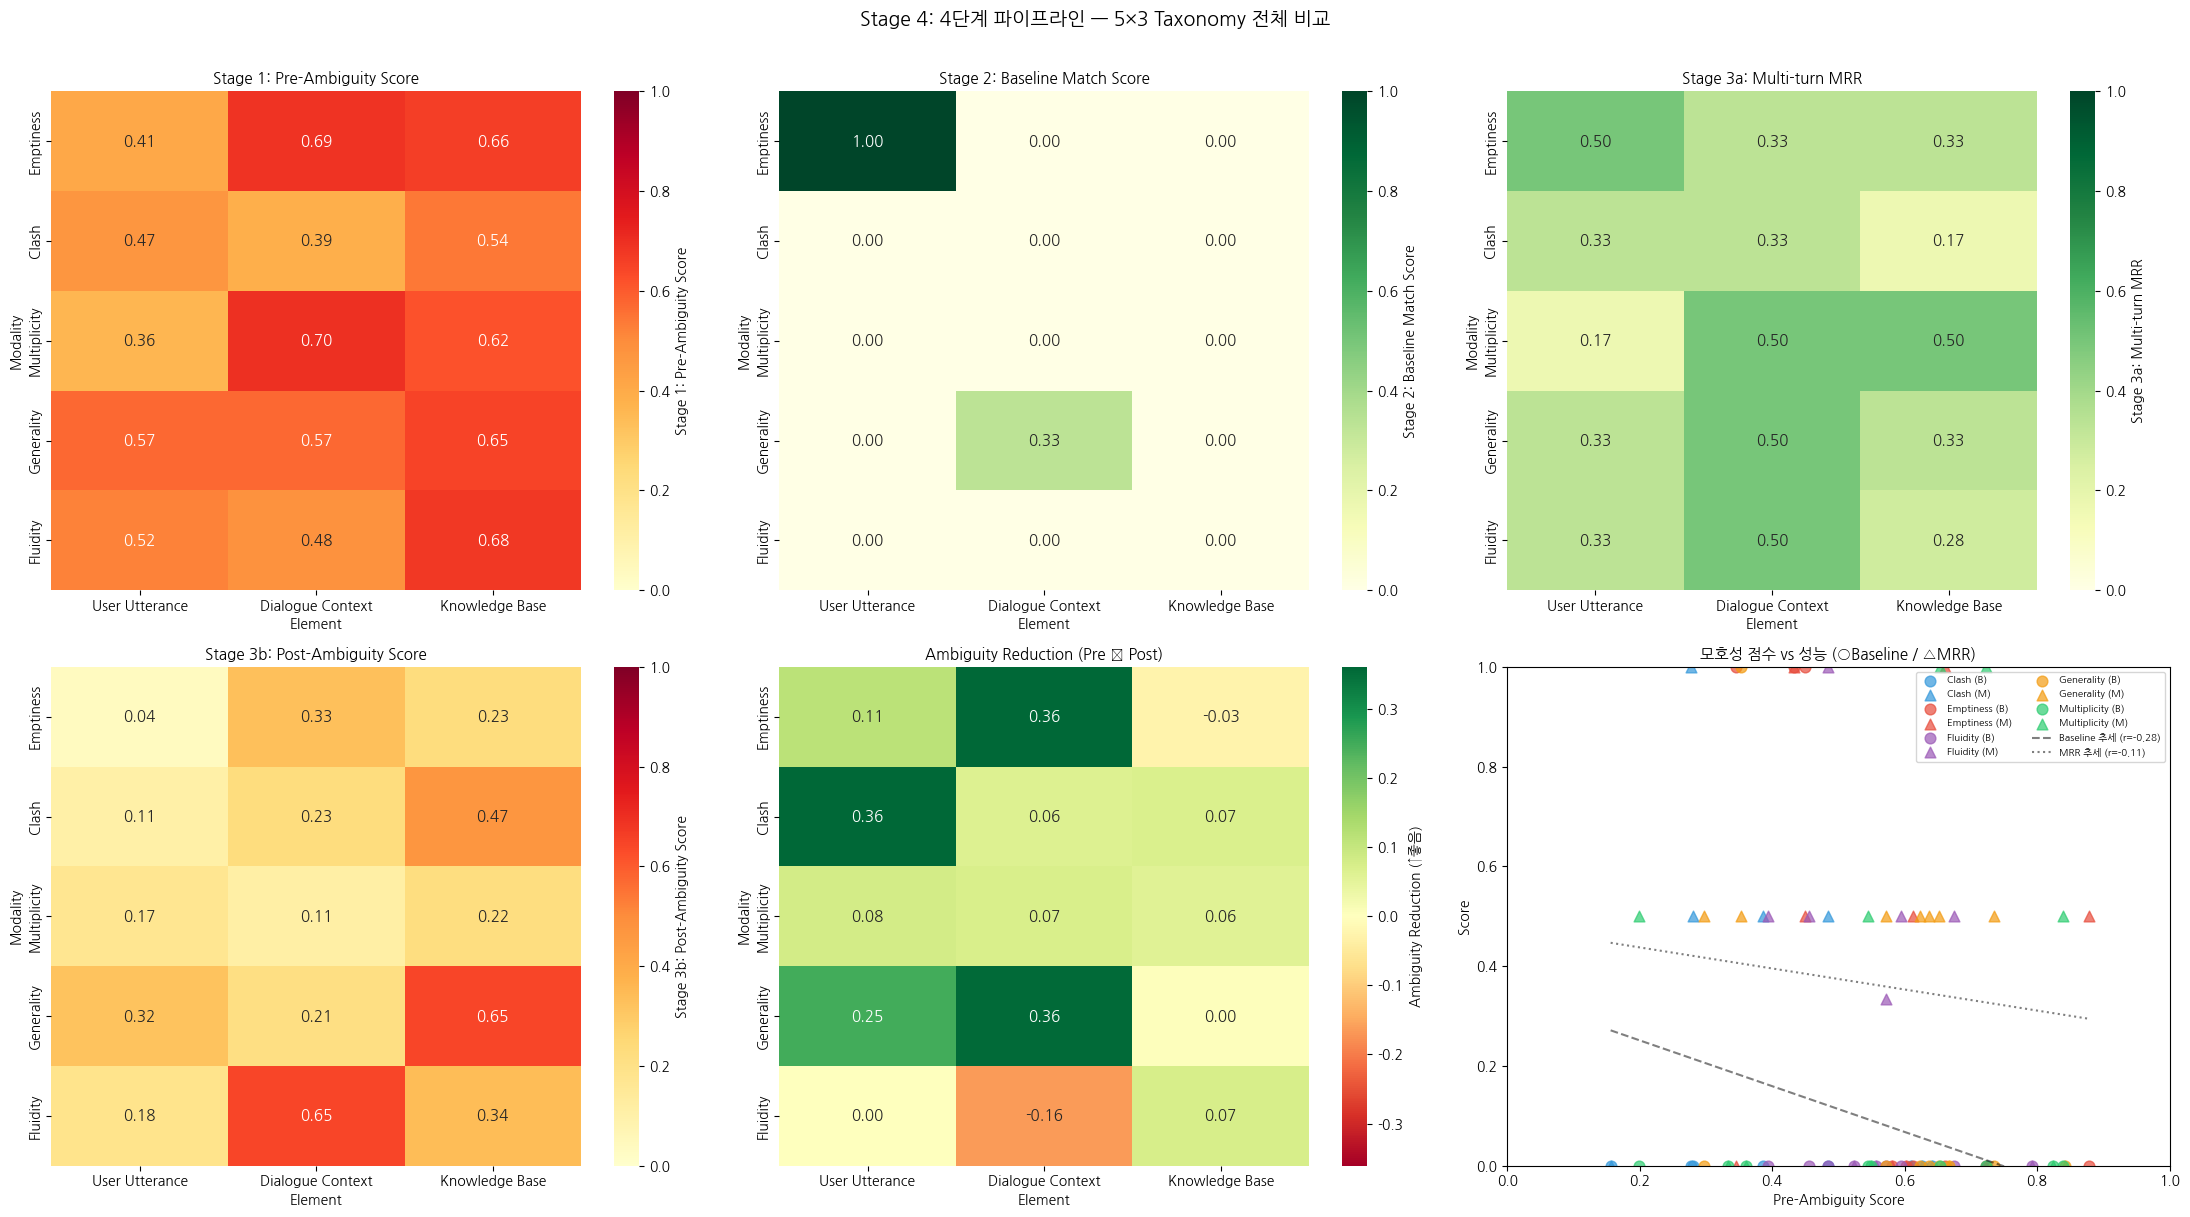

In [17]:
# Stage 4: 전체 파이프라인 — 5×3 Taxonomy 비교 행렬
mat_pre   = np.full((5, 3), np.nan)
mat_base  = np.full((5, 3), np.nan)
mat_mrr   = np.full((5, 3), np.nan)
mat_post  = np.full((5, 3), np.nan)
mat_reduc = np.full((5, 3), np.nan)
cnt       = np.zeros((5, 3))

for _, row in comp_df.iterrows():
    mi = mod_idx(row['modality'])
    ei = elem_idx(row['element'])
    if mi is None or ei is None:
        continue
    def _add(mat, val):
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            mat[mi, ei] = np.nansum([mat[mi, ei] if not np.isnan(mat[mi, ei]) else 0, float(val)])
    _add(mat_pre,   row.get('pre_ambiguity'))
    _add(mat_base,  row.get('baseline_score'))
    _add(mat_mrr,   row.get('mrr_score'))
    _add(mat_post,  row.get('post_ambiguity'))
    _add(mat_reduc, row.get('ambiguity_reduction'))
    cnt[mi, ei] += 1

def _avg(mat):
    return np.divide(mat, cnt, where=cnt > 0, out=np.full_like(mat, np.nan))

avg_pre   = _avg(mat_pre)
avg_base  = _avg(mat_base)
avg_mrr   = _avg(mat_mrr)
avg_post  = _avg(mat_post)
avg_reduc = _avg(mat_reduc)

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# 상단 3개: 단계별 점수 히트맵
for ax, mat, title, cmap in [
    (axes[0, 0], avg_pre,  'Stage 1: Pre-Ambiguity Score',  'YlOrRd'),
    (axes[0, 1], avg_base, 'Stage 2: Baseline Match Score', 'YlGn'  ),
    (axes[0, 2], avg_mrr,  'Stage 3a: Multi-turn MRR',      'YlGn'  ),
]:
    sns.heatmap(np.nan_to_num(mat), ax=ax, cmap=cmap, vmin=0, vmax=1,
                mask=np.isnan(mat), annot=True, fmt='.2f', annot_kws={'fontsize': 11},
                xticklabels=ELEM_KEYS, yticklabels=MODALITIES,
                cbar_kws={'label': title})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Element'); ax.set_ylabel('Modality')

# 하단 좌: Post-Ambiguity
has_post = comp_df['post_ambiguity'].notna().any()
if has_post:
    sns.heatmap(np.nan_to_num(avg_post), ax=axes[1, 0], cmap='YlOrRd', vmin=0, vmax=1,
                mask=np.isnan(avg_post), annot=True, fmt='.2f', annot_kws={'fontsize': 11},
                xticklabels=ELEM_KEYS, yticklabels=MODALITIES,
                cbar_kws={'label': 'Stage 3b: Post-Ambiguity Score'})
    axes[1, 0].set_title('Stage 3b: Post-Ambiguity Score', fontsize=11)
    axes[1, 0].set_xlabel('Element'); axes[1, 0].set_ylabel('Modality')
else:
    axes[1, 0].text(0.5, 0.5, 'Stage 3b 실행 후 확인 가능\n(Post CheckEval)',
                    ha='center', va='center', transform=axes[1, 0].transAxes, fontsize=12)
    axes[1, 0].set_title('Stage 3b: Post-Ambiguity Score', fontsize=11)

# 하단 중: Ambiguity Reduction (발산형 컬러맵)
if has_post and comp_df['ambiguity_reduction'].notna().any():
    abs_max = np.nanmax(np.abs(avg_reduc)) or 0.3
    sns.heatmap(np.nan_to_num(avg_reduc), ax=axes[1, 1], cmap='RdYlGn',
                center=0, vmin=-abs_max, vmax=abs_max,
                mask=np.isnan(avg_reduc), annot=True, fmt='.2f', annot_kws={'fontsize': 11},
                xticklabels=ELEM_KEYS, yticklabels=MODALITIES,
                cbar_kws={'label': 'Ambiguity Reduction (↑좋음)'})
    axes[1, 1].set_title('Ambiguity Reduction (Pre − Post)', fontsize=11)
    axes[1, 1].set_xlabel('Element'); axes[1, 1].set_ylabel('Modality')
else:
    axes[1, 1].text(0.5, 0.5, 'Stage 3b 실행 후 확인 가능\n(Ambiguity Reduction)',
                    ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=12)
    axes[1, 1].set_title('Ambiguity Reduction (Pre − Post)', fontsize=11)

# 하단 우: Scatter — pre-ambiguity vs Baseline / MRR (taxonomy 색상 구분)
ax = axes[1, 2]
v = comp_df.dropna(subset=['pre_ambiguity', 'baseline_score'])
if not v.empty:
    # modality별 색상
    palette = {'Emptiness': '#e74c3c', 'Clash': '#3498db', 'Multiplicity': '#2ecc71',
               'Generality': '#f39c12', 'Fluidity': '#9b59b6'}
    for mod, grp in v.groupby('modality'):
        color = palette.get(mod, '#888888')
        ax.scatter(grp['pre_ambiguity'], grp['baseline_score'],
                   c=color, marker='o', s=60, alpha=0.7, label=f'{mod} (B)')
        if grp['mrr_score'].notna().any():
            ax.scatter(grp['pre_ambiguity'], grp['mrr_score'],
                       c=color, marker='^', s=60, alpha=0.7, label=f'{mod} (M)')
    for col, ls, lbl in [('baseline_score', '--', 'Baseline'), ('mrr_score', ':', 'MRR')]:
        sub = v.dropna(subset=[col])
        if len(sub) >= 2:
            z  = np.polyfit(sub['pre_ambiguity'], sub[col], 1)
            xr = np.linspace(sub['pre_ambiguity'].min(), sub['pre_ambiguity'].max(), 50)
            r  = sub['pre_ambiguity'].corr(sub[col])
            ax.plot(xr, np.polyval(z, xr), ls, color='black', alpha=0.5, label=f'{lbl} 추세 (r={r:.2f})')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Pre-Ambiguity Score'); ax.set_ylabel('Score')
    ax.set_title('모호성 점수 vs 성능 (○Baseline / △MRR)', fontsize=11)
    ax.legend(fontsize=7, ncol=2, loc='upper right')

plt.suptitle('Stage 4: 4단계 파이프라인 — 5×3 Taxonomy 전체 비교', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


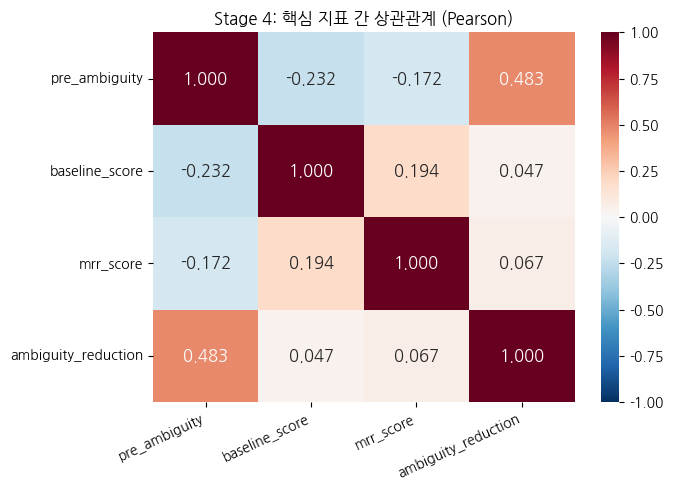


상관관계 해석:
  pre_ambiguity vs baseline_score: -0.232
  pre_ambiguity vs mrr_score: -0.172
  pre_ambiguity vs ambiguity_reduction: 0.483
  mrr_score vs ambiguity_reduction: 0.067


In [18]:
# 상관관계 히트맵
metrics = ['pre_ambiguity', 'baseline_score', 'mrr_score', 'ambiguity_reduction']
corr_df = comp_df[metrics].dropna()

if len(corr_df) >= 5:
    corr_mat = corr_df.corr()
    fig, ax  = plt.subplots(figsize=(7, 5))
    sns.heatmap(corr_mat, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.3f', annot_kws={'fontsize': 12},
                xticklabels=metrics, yticklabels=metrics)
    ax.set_title('Stage 4: 핵심 지표 간 상관관계 (Pearson)', fontsize=12)
    plt.xticks(rotation=25, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

    print('\n상관관계 해석:')
    for a, b in [('pre_ambiguity', 'baseline_score'),
                 ('pre_ambiguity', 'mrr_score'),
                 ('pre_ambiguity', 'ambiguity_reduction'),
                 ('mrr_score',     'ambiguity_reduction')]:
        if a in corr_mat and b in corr_mat:
            print(f'  {a} vs {b}: {corr_mat.loc[a, b]:.3f}')
else:
    print('상관관계 분석을 위한 완전한 데이터 부족 — Stage 3b 실행 필요')


In [19]:
# 통합 결과 저장
out_path = RESULTS_DIR / f'framework_results_{MODEL.replace("/", "_")}.json'
output = {
    'config': {
        'model': MODEL, 'max_clarification_turns': MAX_CLARIFICATION_TURNS,
        'question_version': QUESTION_VERSION, 'timestamp': datetime.now().isoformat(),
    },
    'summary': {
        'stage1_avg_ambiguity':   float(comp_df['pre_ambiguity'].mean())    if comp_df['pre_ambiguity'].notna().any()    else None,
        'stage2_baseline_score':  float(comp_df['baseline_score'].mean())   if comp_df['baseline_score'].notna().any()   else None,
        'stage3_mrr':             float(comp_df['mrr_score'].mean())         if comp_df['mrr_score'].notna().any()         else None,
        'stage3b_post_ambiguity': float(comp_df['post_ambiguity'].mean())   if comp_df['post_ambiguity'].notna().any()   else None,
        'avg_ambiguity_reduction':float(comp_df['ambiguity_reduction'].mean()) if comp_df['ambiguity_reduction'].notna().any() else None,
    },
    'per_scenario': comp_df.to_dict(orient='records'),
}
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2, default=str)

print(f'✓ 통합 결과 저장: {out_path}')
print('\n=== 최종 요약 ===')
for k, v in output['summary'].items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')


✓ 통합 결과 저장: /home/mikelee/CheckEval/results/ambiguity_framework/framework_results_gpt-5.4-mini.json

=== 최종 요약 ===
  stage1_avg_ambiguity: 0.5539
  stage2_baseline_score: 0.0889
  stage3_mrr: 0.3630
  stage3b_post_ambiguity: 0.3995
  avg_ambiguity_reduction: 0.1565


---
## 요약

### 파이프라인 흐름
```
[Stage 1] CheckEval 어노테이션
          ↓ ambiguity_score: 0(명확) → 1(모호)
[Stage 2] 모호 상태 → 직접 API 호출 (Baseline)
          ↓ match_score: candidate_apis 일치 여부
[Stage 3a] 멀티 턴 명확화 → API 호출
          ↓ MRR: 몇 번째 턴에 올바른 API?
[Stage 3b] 명확화 후 CheckEval 재측정
          ↓ ambiguity_reduction: 모호성이 얼마나 줄었나?
[Stage 4] 비교 분석
          → 상관관계 / 개선 효과 / 시각화
```

### 해석 가이드
| 관계 | 기대 방향 | 의미 |
|------|-----------|------|
| pre_ambiguity ↑ → baseline_score ↓ | 음의 상관 | CheckEval이 유효한 모호성 신호 |
| stage2 baseline < stage3 MRR | Baseline < Multi-turn | 명확화 대화의 효과 입증 |
| ambiguity_reduction > 0 | 양수 | 명확화가 실제로 모호성 해소 |
